# Character Segmentation

Here we use histogram methods to identify border boxes

Limitations (a lot):
- Text needs decently clear background
- Extremely sensitive to Hyperparameters
- Rotated or distorted text doesn't behave well
- Very messy handwritting will missegmentate

Solution? idk, maybe try pre built models or something?

In [107]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [108]:
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import tensorflow as tf
from PIL import Image
from pathlib import Path

model = tf.keras.models.load_model("drive/MyDrive/ETL9B/KanjiOCR_2-1.keras")

with open("drive/MyDrive/ETL9B/Class2Number.json", "r", encoding="utf-8") as f:
    Character2Number = json.load(f)
Number2Letter = {int(k): v for k, v in Character2Number.items()}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 2 · Hyper Params

In [ ]:
IMAGE_PATH = "drive/MyDrive/ETL9B/ComputerSegmentationTest.png"  
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest.png"   
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest (1).png"
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest3.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/OldSegmentationTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuSegmentationTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/TVSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/KarafuruHandwrittenTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/YourNameHandwrittenTest.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/HandwrittenSegmentationTest2.png"
IMAGE_PATH = "drive/MyDrive/ETL9B/BlurrySegmentationTest.png"

ORIENTATION = 0 # 0/1 Horizontal/Vertical

BINARISE_THRESHOLD = 127 #Irrelevant now that we use Otsu's

# Thresholds to identify lines and characters based on their perpendicular intensity
# Note: Threshold is relative to the max value of the projection

LINE_INK_THRESHOLD = 0.05 
CHAR_INK_THRESHOLD = 0.00

#Lines with gaps smaller than 4 pixels get merged
#Would be nice to change this maybe to a relative method like the one above
LINE_MERGE_GAP = 4

#Lines smaller than 4 pixels get discarded
#Same comment from the previous hyperparam
LINE_MIN_HEIGHT = 4

#Same but for characters
CHAR_MERGE_GAP = 10
CHAR_MIN_WIDTH = 1

#Confidence threshold doesn't really matter for current model bc the guy has always hella confidence
CONFIDENCE_THRESHOLD = 0.05
#How many "guesses" the model gives us
TOP_N = 5

#Max and min aspect ratios for character segmentation alongside their recursive adjustment factors
MAX_FATNESS = 1.2
THRESHOLD_INCREASE_ON_FATTIE = 0.05

MAX_THINNESS = 0.5
SMOOTHING_FACTOR = 0.55

#When orientation is vertical we swap stuff
if ORIENTATION == 1:
    LINE_INK_THRESHOLD, CHAR_INK_THRESHOLD = CHAR_INK_THRESHOLD, LINE_INK_THRESHOLD
    LINE_MERGE_GAP, CHAR_MERGE_GAP = CHAR_MERGE_GAP, LINE_MERGE_GAP
    LINE_MIN_HEIGHT, CHAR_MIN_WIDTH = CHAR_MIN_WIDTH, LINE_MIN_HEIGHT
    MAX_FATNESS, MAX_THINNESS = MAX_THINNESS, MAX_FATNESS

##### Functions

In [141]:

def ShowProj(img):
    plt.imshow(img[np.newaxis, :], aspect='auto', cmap='viridis')
    plt.show()

def ShowImage(img):
    plt.imshow(img, cmap="binary_r")
    plt.show()

def LoadBinary(path):
    
    greyscale = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    
    _, binary = cv2.threshold(greyscale, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return greyscale, binary


def FindLimits(proj, threshold, gap):
    
    max = np.max(proj)
    relativeThreshold = max*threshold
    
    #print(f"Relative Thres {relativeThreshold} to {max}")
    
    active = proj > relativeThreshold
    limits  = []
    
    in_char = False 
    start =  0
    for i, val in enumerate(proj):
        if not in_char and val >= relativeThreshold: #Going into a Character
            in_char = True
            start = i
        elif in_char and val < relativeThreshold: #Going out of Character
            in_char = False
            limits.append((start, i - 1))
            
    if in_char:
        limits.append((start, len(active) - 1)) #In case we end loop in_char

    merged = []
    for limit in limits:
        if merged and limit[0] - merged[-1][1] <= gap:
            merged[-1] = (merged[-1][0], limit[1])
        else:
            merged.append(list(limit))
    return merged


def DetectLines(binary, threshold, gap, orientation):
    projH = binary.sum(axis = 1 if orientation==0 else 0) 
    return FindLimits(projH, threshold, gap)


def DetectCharacters(binarySentence, threshold, gap, minW, maxFatness, maxThiness, lineH, orientation):
    projV = binarySentence.sum(axis=orientation)   
    limits = FindLimits(projV, threshold, gap)
    
    #print(binarySentence.shape)
    
    #Big problems to solve here:
    #1 - Tiny irrelevant characters
    #2 - Kanjis with empty space in between, like 能
    #3 - Kanji pairs getting connected toghether
    
    filtered = [(start, end) for start, end in limits if end - start + 1 >= minW]
    
    noFatties = []
    for limit in filtered:
        start, end = limit
        if end - start + 1 > lineH * maxFatness:
            if gap == 0:
                noFatties.append(limit)
            else:
                #print("Fattie detected")
                unfatties = DetectCharacters(binarySentence[start:end, :] if orientation == 1 else binarySentence[:, start:end], threshold + THRESHOLD_INCREASE_ON_FATTIE, gap-1, minW, maxFatness, maxThiness, lineH, orientation)
                
                for u in unfatties:
                    s,e= u
                    noFatties.append((start+s, start+e))
        else:
            noFatties.append(limit)
            
    noLankys = []
    for i, limit in enumerate(noFatties):
        if i == len(noFatties) - 1:
            noLankys.append(limit)
            continue
        
        start, end = limit
        if end - start + 1 < lineH * maxThiness:
            nextStart, nextEnd = noFatties[i+1]
            if nextEnd - nextStart + 1 < lineH / maxThiness and not(nextEnd - start + 1 > lineH * maxFatness):
                
                #print("Lanky pair detected")
                noFatties.remove(noFatties[i+1])
                noLankys.append((start, nextEnd))
            else:
                noLankys.append(limit)
                
                
        else:
            noLankys.append(limit)
    
    return noLankys

def CenterInk(binary):
    rows = np.any(binary, axis=1)   
    cols = np.any(binary, axis=0) 

    if not rows.any():
        return binary 

    rowMin, rowMax = np.where(rows)[0][[0, -1]]
    colMin, colMax = np.where(cols)[0][[0, -1]]

    character = binary[rowMin:rowMax+1, colMin:colMax+1]
    heigth, width = character.shape

    totalHeight, totalWidth  = binary.shape
    result = np.zeros_like(binary)
    offSetY = (totalHeight - heigth) // 2
    offSetX = (totalWidth - width) // 2
    result[ offSetY : offSetY + heigth, offSetX : offSetX + width ] = character

    return result

def PreprocessChar(img, padding):
    h, w = img.shape
    size = int(padding*max(h, w))
    
    pad = np.full((size, size), 255, dtype=np.uint8)  
    offsetY = (size - h) // 2
    offsetX = (size - w) // 2
    
    pad[ offsetY : offsetY+h, offsetX : offsetX+w ] = img

    img = Image.fromarray(pad).resize((63, 64), Image.LANCZOS)
    
    arr = np.array(img).astype("float16") / 255.0
    arr = 1.0 - arr
    arr = (arr >= SMOOTHING_FACTOR).astype(np.uint8) #Adjust to get rid of fades
    
    arr = CenterInk(arr)
    
    arr = arr[:, :, np.newaxis]
    
    
    
    return np.expand_dims(arr, axis=0)


def Predict(img):
    preImg = PreprocessChar(img, 1.2)
    #ShowImage(preImg[0])
    probs = model.predict(preImg, verbose=0)[0]
    top = np.argsort(probs)[::-1][:TOP_N]
    return [(Number2Letter.get(i, f"#{i}"), float(probs[i])) for i in top]


print("Functions defined")


Functions defined


# Classification

In [78]:
MINIMIZABLE_CHARACTERS = {"つ":"っ", "よ":"ょ", "ゆ":"ゅ", "や":"ゃ", "ツ":"ッ", "ヨ":"ョ", "ユ":"ュ", "ヤ":"ャ"}

def AddMinimizables(predicts):
    print(predicts)

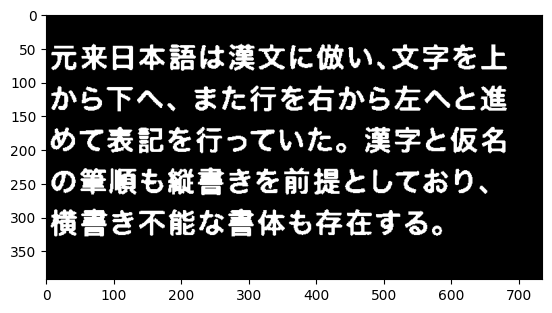

Image: 735×392 px
Found 5 line(s)
  Line 1: 16 character segments
  Line 2: 16 character segments
  Line 3: 16 character segments
  Line 4: 16 character segments
  Line 5: 14 character segments
Classification done


In [ ]:

grey, binary = LoadBinary(IMAGE_PATH)
H, W = grey.shape

# ShowImage(grey)
ShowImage(binary)
print(f"Image: {W}×{H} px")


lines = DetectLines(binary, LINE_INK_THRESHOLD, LINE_MERGE_GAP, ORIENTATION)
print(f"Found {len(lines)} lines")

results = []  

for lineID, (lineStart, lineEnd) in enumerate(lines):
    if ORIENTATION == 0:
        strip = binary[ lineStart : lineEnd+1, : ]
        grey_strip = grey[ lineStart : lineEnd+1 , : ]
    else:
        strip = binary[ :, lineStart : lineEnd+1 ]
        grey_strip = grey[ :, lineStart : lineEnd+1 ]

    charSegments  = DetectCharacters(strip, CHAR_INK_THRESHOLD, CHAR_MERGE_GAP, CHAR_MIN_WIDTH, MAX_FATNESS, MAX_THINNESS, lineEnd - lineStart + 1, ORIENTATION)
    
    print(f"> Line {lineID+1}: {len(charSegments)} character segments")

    lineResults = []
    for charStart, charEnd in charSegments:
        if ORIENTATION == 0:
            crop = grey_strip[:, charStart:charEnd+1]
            bbox = (charStart, lineStart, charEnd, lineEnd)
        else:
            crop = grey_strip[charStart:charEnd+1, :]
            bbox = (lineStart, charStart, lineEnd, charEnd)

        preds = Predict(crop)
        
        for char, prob in preds:
            if char in MINIMIZABLE_CHARACTERS.keys():
                preds.append((MINIMIZABLE_CHARACTERS[char], prob))
            
        
        lineResults.append({"bbox": bbox, "preds": preds})

    results.append(lineResults)

print("Classification done")

## 5 · Visualise segmentation

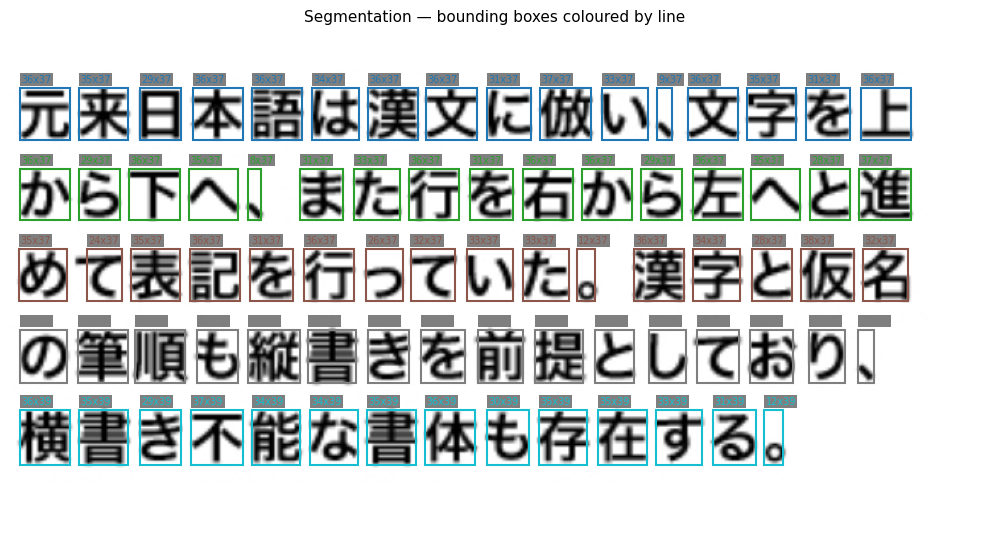

✓ saved → segmentation_vis.png


In [ ]:
fig, ax = plt.subplots(figsize=(max(10, W / 80), max(6, H / 80)))
ax.imshow(grey, cmap="gray", vmin=0, vmax=255)

colours = plt.cm.tab10(np.linspace(0, 1, max(len(results), 1)))

for lineID, lineResults in enumerate(results):
    
    colour = colours[lineID]
    
    for char_data in lineResults:
        
        startX, startY, endX, endY = char_data["bbox"]
        
        #Box
        rect = mpatches.FancyBboxPatch((startX, startY), endX - startX, endY - startY, boxstyle="square,pad=1", linewidth=1.5, edgecolor=colour, facecolor="none")
        ax.add_patch(rect)
        
ax.axis("off")
ax.set_title("Segmentation Boundary Boxes", fontsize=11)
plt.tight_layout()
plt.show()

## 6 · Reconstructed text

In [ ]:
fullText = []

if ORIENTATION == 1:
    results.reverse()

for lineID, lineResults in enumerate(results):

    lineTxt = ""
    
    for char_data in lineResults:
        topChar, topConfidence = char_data["preds"][0]
        lineTxt += topChar if topConfidence >= CONFIDENCE_THRESHOLD else "🙈"
        
    fullText.append(lineTxt)

print("\n".join(fullText))

════════════════════════════════════════
RECONSTRUCTED TEXT
════════════════════════════════════════
Line 1: 元来日本語は漢攻に倣い、攻字を上
Line 2: から下へ、また行を右から左へと進
Line 3: めて張記を行つていた。漢字と仮名
Line 4: の筆順も縦書きを前提としてお口、
Line 5: 横書き不能な書体も存在する。
════════════════════════════════════════

Full text:
元来日本語は漢攻に倣い、攻字を上
から下へ、また行を右から左へと進
めて張記を行つていた。漢字と仮名
の筆順も縦書きを前提としてお口、
横書き不能な書体も存在する。


## 7. Character Probabilities

In [ ]:
sentenceDistributions = []
sentenceID = -1

for lineID, lineResults in enumerate(results):
    
    print(f"-- Line {lineID+1} --")
    
    for charID, charData in enumerate(lineResults):
        
        print(f"  Char {charID+1}:")
        
        sentenceDistributions.append([])
        sentenceID += 1
        
        for rank, (char, conf) in enumerate(charData["preds"]):
            
            bar = "█" * int(conf * 30)
            marker = " ◀" if rank == 0 else ""
            
            print(f"    #{rank+1}  {char}  {conf*100:5.1f}%  {bar}{marker}")
            
            sentenceDistributions[sentenceID].append((char, conf))


── Line 1 ──
  Char 1:
    #1  元  100.0%  █████████████████████████████ ◀
    #2  玩    0.0%  
    #3  瓦    0.0%  
    #4  示    0.0%  
    #5  死    0.0%  
  Char 2:
    #1  来   51.0%  ███████████████ ◀
    #2  爽   42.2%  ████████████
    #3  洪    4.7%  █
    #4  瑛    1.8%  
    #5  挟    0.1%  
  Char 3:
    #1  日  100.0%  █████████████████████████████ ◀
    #2  目    0.0%  
    #3  田    0.0%  
    #4  ロ    0.0%  
    #5  巳    0.0%  
  Char 4:
    #1  本   99.8%  █████████████████████████████ ◀
    #2  体    0.2%  
    #3  奉    0.0%  
    #4  裕    0.0%  
    #5  卒    0.0%  
  Char 5:
    #1  語  100.0%  ██████████████████████████████ ◀
    #2  誘    0.0%  
    #3  諮    0.0%  
    #4  話    0.0%  
    #5  譜    0.0%  
  Char 6:
    #1  は  100.0%  █████████████████████████████ ◀
    #2  妹    0.0%  
    #3  ほ    0.0%  
    #4  魅    0.0%  
    #5  峨    0.0%  
  Char 7:
    #1  漢  100.0%  █████████████████████████████ ◀
    #2  漂    0.0%  
    #3  簿    0.0%  
    #4  譲    0.0%  
    #5  濃    0.0%  

In [51]:
!pip install fugashi unidic_lite

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

LM_NAME = "cl-tohoku/bert-base-japanese-char"
tokenizer = AutoTokenizer.from_pretrained(LM_NAME)
lm = AutoModelForMaskedLM.from_pretrained(LM_NAME)
lm.eval()
print("Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: cl-tohoku/bert-base-japanese-char
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ LM loaded


In [ ]:
def TransformerRerank(sentenceDistributions, alpha=0.6):

    n = len(sentenceDistributions)

    sequence = [candidates[0][0] for candidates in sentenceDistributions]

    for pos in range(n):
        
        candidates = sentenceDistributions[pos]  
        
        maskedSeq = sequence.copy()
        maskedSeq[pos] = "[MASK]"
        maskedText = "".join(maskedSeq)

        inputs  = tokenizer(maskedText, return_tensors="pt")
        maskID = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0][0]

        with torch.no_grad():
            logits = lm(**inputs).logits          
        transformerProbs = torch.softmax(logits[0, maskID], dim=-1)

       
        bestChar, bestScore = None, -1

        for char, cnnProb in candidates:
            
            token_ids = tokenizer.encode(char, add_special_tokens=False)
            if not token_ids:
                continue  

            transformerProb = float(transformerProbs[token_ids[0]])
            
            score = (1 - alpha) * cnnProb + alpha * transformerProb

            if score > bestScore:
                bestScore, bestChar = score, char

        if bestChar is not None:
            sequence[pos] = bestChar

    return sequence


corrected = TransformerRerank(sentenceDistributions, alpha=1)
print("CNN top-1: ", "".join(d[0][0] for d in sentenceDistributions))
print("Corrected: ", "".join(corrected))

CNN top-1:  元来日本語は漢攻に倣い、攻字を上から下へ、また行を右から左へと進めて張記を行つていた。漢字と仮名の筆順も縦書きを前提としてお口、横書き不能な書体も存在する。
Corrected:  元来日本語は漢文に倣い、文字を上から下へ、また行を右から左へと進めて表記を行っていた。漢字と仮名の筆順も縦書きを前提としておら、横書き不能な書体も存在する。


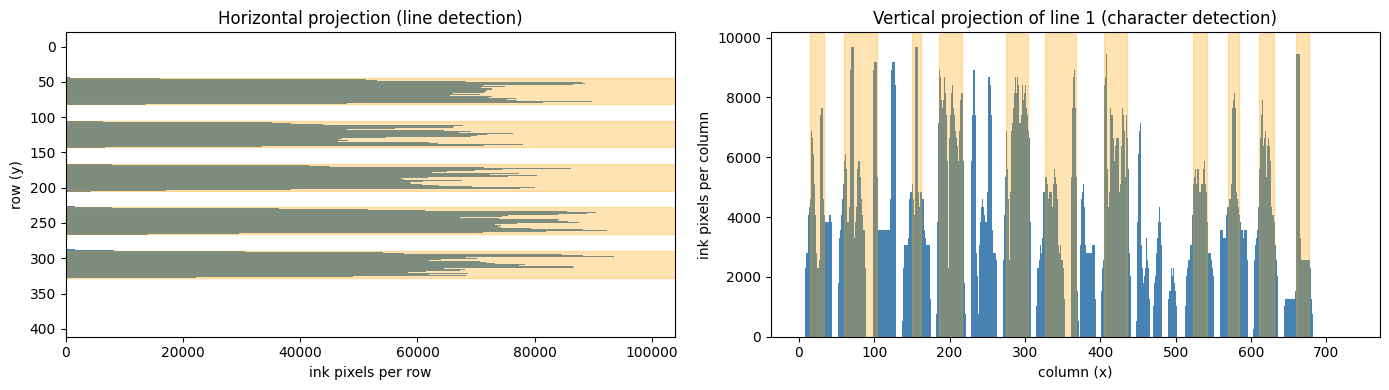

✓ saved → projection_profiles.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if ORIENTATION == 0:
    lineProj = binary.sum(axis=1)
    axes[0].barh(np.arange(H), lineProj, color="steelblue", height=1)
    
    #Hitbox of detected lines
    for start, end in lines:
        axes[0].axhspan(start, end, color="orange", alpha=0.3)
        
    axes[0].invert_yaxis()
    axes[0].set_title("Horizontal projection (line detection)")
    axes[0].set_xlabel("Pixels per row")
    axes[0].set_ylabel("row (y)")
    
else:
    lineProj = binary.sum(axis=0)
    axes[0].bar(np.arange(W), lineProj, color="steelblue", width=1)
    
    for start, end in lines:
        axes[0].axvspan(start, end, color="orange", alpha=0.3)
        
    axes[0].set_title("Vertical projection (line detection)")
    axes[0].set_xlabel("column (x)")
    axes[0].set_ylabel("Pixels per column")

if lines:
    line2Display = 0
    start, end = lines[line2Display]
    
    if ORIENTATION == 0:
        strip = binary[start:end+1, :]
        char_proj = strip.sum(axis=0)

        char_segs = DetectCharacters(strip, CHAR_INK_THRESHOLD, CHAR_MERGE_GAP, CHAR_MIN_WIDTH, MAX_FATNESS, MAX_THINNESS, end - start + 1, ORIENTATION)
        axes[1].bar(np.arange(W), char_proj, color="steelblue", width=1)
        
        for x0, x1 in char_segs:
            axes[1].axvspan(x0, x1, color="orange", alpha=0.3)
            
        axes[1].set_title(f"Vertical projection of line {line2Display} (character detection)")
        axes[1].set_xlabel("column (x)")
        axes[1].set_ylabel("Pixels per column")
    else:
        strip = binary[:, start:end+1]
        char_proj = strip.sum(axis=1)
        
        char_segs = DetectCharacters(strip, CHAR_INK_THRESHOLD, CHAR_MERGE_GAP, CHAR_MIN_WIDTH, MAX_FATNESS, MAX_THINNESS, end - start + 1, ORIENTATION)
        axes[1].barh(np.arange(H), char_proj, color="steelblue", height=1)
        
        for y0, y1 in char_segs:
            axes[1].axhspan(y0, y1, color="orange", alpha=0.3)
            
        axes[1].invert_yaxis()
        axes[1].set_title(f"Horizontal projection of line {line2Display} (character detection)")
        axes[1].set_xlabel("Pixels per row")
        axes[1].set_ylabel("row (y)")

plt.tight_layout()
plt.show()